In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve,
    accuracy_score
)
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings("ignore")

In [21]:
# STEP 1 — Load datasets

 
dataset_full  = pd.read_csv("dataset_full.csv")
dataset_small = pd.read_csv("dataset_small.csv")
 
print("=" * 55)
print("  Phishing Detection — XGBoost + Random Forest + Drift Analysis")
print("=" * 55)
 
print(f"\ndataset_full  : {dataset_full.shape[0]} rows, {dataset_full.shape[1]} columns")
print(f"dataset_small : {dataset_small.shape[0]} rows, {dataset_small.shape[1]} columns")
 
# target column is "phishing"  (0 = legit, 1 = phishing)
TARGET = "phishing"
 
print(f"\nClass distribution in dataset_full:")
print(f"  Legit    (0) : {(dataset_full[TARGET] == 0).sum()}")
print(f"  Phishing (1) : {(dataset_full[TARGET] == 1).sum()}")

  Phishing Detection — XGBoost + Random Forest + Drift Analysis

dataset_full  : 88647 rows, 112 columns
dataset_small : 58645 rows, 112 columns

Class distribution in dataset_full:
  Legit    (0) : 58000
  Phishing (1) : 30647


In [22]:
# preview Full datasets
df_full  = pd.read_csv("dataset_full.csv")
print("dataset_full — first 10 rows:")
print(df_full.head(10))



dataset_full — first 10 rows:
   qty_dot_url  qty_hyphen_url  qty_underline_url  qty_slash_url  \
0            3               0                  0              1   
1            5               0                  1              3   
2            2               0                  0              1   
3            4               0                  2              5   
4            2               0                  0              0   
5            1               0                  0              2   
6            2               0                  0              0   
7            2               0                  0              3   
8            2               0                  0              0   
9            1               0                  0              2   

   qty_questionmark_url  qty_equal_url  qty_at_url  qty_and_url  \
0                     0              0           0            0   
1                     0              3           0            2   
2                   

In [23]:
# preview Small datasets
df_small = pd.read_csv("dataset_small.csv")
print("\ndataset_small — first 10 rows:")
print(df_small.head(10))


dataset_small — first 10 rows:
   qty_dot_url  qty_hyphen_url  qty_underline_url  qty_slash_url  \
0            2               0                  0              0   
1            4               0                  0              2   
2            1               0                  0              1   
3            2               0                  0              3   
4            1               1                  0              4   
5            1               1                  0              4   
6            1               0                  0              3   
7            2               0                  0              0   
8            2               0                  0              2   
9            1               0                  0              1   

   qty_questionmark_url  qty_equal_url  qty_at_url  qty_and_url  \
0                     0              0           0            0   
1                     0              0           0            0   
2                 

In [24]:
# STEP 2 — Prepare features and labels
# -------------------------------------------------------
 
X_full  = dataset_full.drop(columns=[TARGET])
y_full  = dataset_full[TARGET]
 
X_small = dataset_small.drop(columns=[TARGET])
y_small = dataset_small[TARGET]
 
# keep only columns shared between both datasets
shared_cols = [col for col in X_full.columns if col in X_small.columns]
X_full  = X_full[shared_cols]
X_small = X_small[shared_cols]
 
print(f"\nNumber of features used : {len(shared_cols)}")
 
# split full dataset — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_full
)
 
print(f"Training samples        : {len(X_train)}")
print(f"Testing  samples        : {len(X_test)}")


Number of features used : 111
Training samples        : 70917
Testing  samples        : 17730


In [25]:
# STEP 3 — Train XGBoost model

print("Training XGBoost model...")

model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "logloss",
    random_state     = 42
)

model.fit(X_train, y_train)
print("XGBoost training complete.")

joblib.dump(model, "phishing_model.pkl")
print("XGBoost model saved  →  phishing_model.pkl")




Training XGBoost model...
XGBoost training complete.
XGBoost model saved  →  phishing_model.pkl


In [26]:
# STEP 3B — Train Random Forest model
# -------------------------------------------------------

print("Training Random Forest model...")

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    random_state = 42
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete.")

joblib.dump(rf_model, "rf_model.pkl")
print("Random Forest model saved  →  rf_model.pkl")

Training Random Forest model...
Random Forest training complete.
Random Forest model saved  →  rf_model.pkl


In [27]:
# STEP 4 — Evaluate XGBoost on test set

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("XGBoost Performance on Test Set:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred,
                            target_names=["Legit", "Phishing"],
                            labels=[0, 1]))

# -------------------------------------------------------
# STEP 4B — Evaluate Random Forest on test set
# -------------------------------------------------------

rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Performance on Test Set:")
print(f"  Accuracy : {accuracy_score(y_test, rf_pred):.2%}")
print(classification_report(y_test, rf_pred,
                            target_names=["Legit", "Phishing"],
                            labels=[0, 1]))

# -------------------------------------------------------
# STEP 4C — Comparison table
# -------------------------------------------------------

print("" + "=" * 50)
print("  Model Comparison Summary")
print("=" * 50)
print(f"  XGBoost       Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(f"  Random Forest Accuracy : {accuracy_score(y_test, rf_pred):.2%}")
xgb_f1 = classification_report(y_test, y_pred, output_dict=True, labels=[0,1])["weighted avg"]["f1-score"]
rf_f1  = classification_report(y_test, rf_pred, output_dict=True, labels=[0,1])["weighted avg"]["f1-score"]
print(f"  XGBoost       F1 Score : {xgb_f1:.2%}")
print(f"  Random Forest F1 Score : {rf_f1:.2%}")
print("=" * 50)
winner = "XGBoost" if accuracy_score(y_test, y_pred) >= accuracy_score(y_test, rf_pred) else "Random Forest"
print(f"  Winner : {winner}")
print("=" * 50)

XGBoost Performance on Test Set:
  Accuracy : 96.36%
              precision    recall  f1-score   support

       Legit       0.97      0.97      0.97     11600
    Phishing       0.94      0.95      0.95      6130

    accuracy                           0.96     17730
   macro avg       0.96      0.96      0.96     17730
weighted avg       0.96      0.96      0.96     17730

Random Forest Performance on Test Set:
  Accuracy : 95.28%
              precision    recall  f1-score   support

       Legit       0.97      0.96      0.96     11600
    Phishing       0.92      0.94      0.93      6130

    accuracy                           0.95     17730
   macro avg       0.95      0.95      0.95     17730
weighted avg       0.95      0.95      0.95     17730

  Model Comparison Summary
  XGBoost       Accuracy : 96.36%
  Random Forest Accuracy : 95.28%
  XGBoost       F1 Score : 96.37%
  Random Forest F1 Score : 95.30%
  Winner : XGBoost


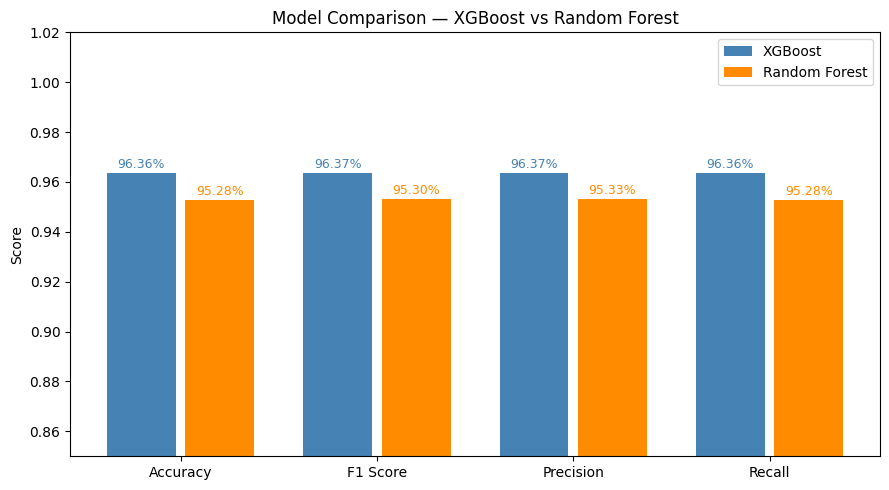

Saved: model_comparison_chart.png

Winner based on accuracy : XGBoost
  XGBoost       : 96.36%
  Random Forest : 95.28%


In [28]:
# STEP 4D — Graph: Model Comparison Chart — XGBoost vs Random Forest

xgb_acc  = accuracy_score(y_test, y_pred)
rf_acc   = accuracy_score(y_test, rf_pred)
xgb_f1   = classification_report(y_test, y_pred,  output_dict=True, labels=[0,1])["weighted avg"]["f1-score"]
rf_f1    = classification_report(y_test, rf_pred, output_dict=True, labels=[0,1])["weighted avg"]["f1-score"]
xgb_prec = classification_report(y_test, y_pred,  output_dict=True, labels=[0,1])["weighted avg"]["precision"]
rf_prec  = classification_report(y_test, rf_pred, output_dict=True, labels=[0,1])["weighted avg"]["precision"]
xgb_rec  = classification_report(y_test, y_pred,  output_dict=True, labels=[0,1])["weighted avg"]["recall"]
rf_rec   = classification_report(y_test, rf_pred, output_dict=True, labels=[0,1])["weighted avg"]["recall"]

metrics  = ["Accuracy", "F1 Score", "Precision", "Recall"]
xgb_vals = [xgb_acc, xgb_f1, xgb_prec, xgb_rec]
rf_vals  = [rf_acc,  rf_f1,  rf_prec,  rf_rec]

x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - 0.2, xgb_vals, 0.35, label="XGBoost",       color="steelblue")
bars2 = ax.bar(x + 0.2, rf_vals,  0.35, label="Random Forest", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — XGBoost vs Random Forest")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.2%}",
            ha="center", fontsize=9, color="steelblue")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.2%}",
            ha="center", fontsize=9, color="darkorange")

plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150)
plt.show()
print("Saved: model_comparison_chart.png")

winner = "XGBoost" if xgb_acc >= rf_acc else "Random Forest"
print(f"\nWinner based on accuracy : {winner}")
print(f"  XGBoost       : {xgb_acc:.2%}")
print(f"  Random Forest : {rf_acc:.2%}")

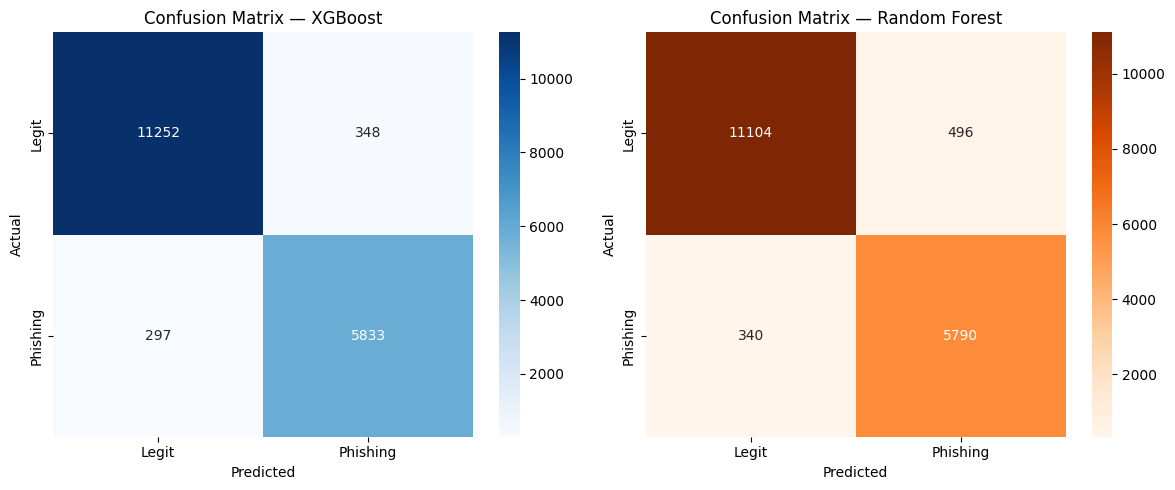

Saved: confusion_matrix.png


In [29]:
# STEP 5 — Graph 1: Confusion Matrix — XGBoost vs Random Forest

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Phishing"],
            yticklabels=["Legit", "Phishing"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix — XGBoost")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Legit", "Phishing"],
            yticklabels=["Legit", "Phishing"],
            ax=axes[1])
axes[1].set_title("Confusion Matrix — Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

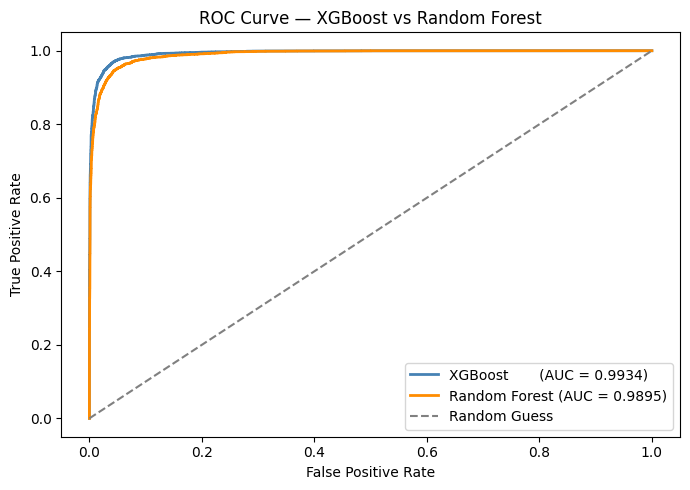

Saved: roc_curve.png


In [30]:
# STEP 6 — Graph 2: ROC Curve — XGBoost vs Random Forest

fpr,    tpr,    _ = roc_curve(y_test, y_pred_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_prob)
roc_auc    = auc(fpr,    tpr)
rf_roc_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr,    tpr,    color="steelblue",  lw=2,
         label=f"XGBoost       (AUC = {roc_auc:.4f})")
plt.plot(rf_fpr, rf_tpr, color="darkorange", lw=2,
         label=f"Random Forest (AUC = {rf_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--",
         label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost vs Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print("Saved: roc_curve.png")

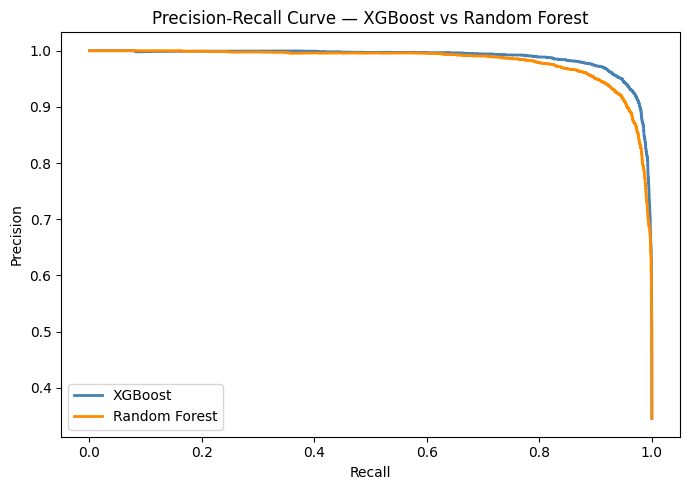

Saved: precision_recall_curve.png


In [30]:
# STEP 7 — Graph 3: Precision-Recall Curve — XGBoost vs Random Forest

precision,    recall,    _ = precision_recall_curve(y_test, y_pred_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall,    precision,    color="steelblue",  lw=2, label="XGBoost")
plt.plot(rf_recall, rf_precision, color="darkorange", lw=2, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost vs Random Forest")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150)
plt.show()
print("Saved: precision_recall_curve.png")

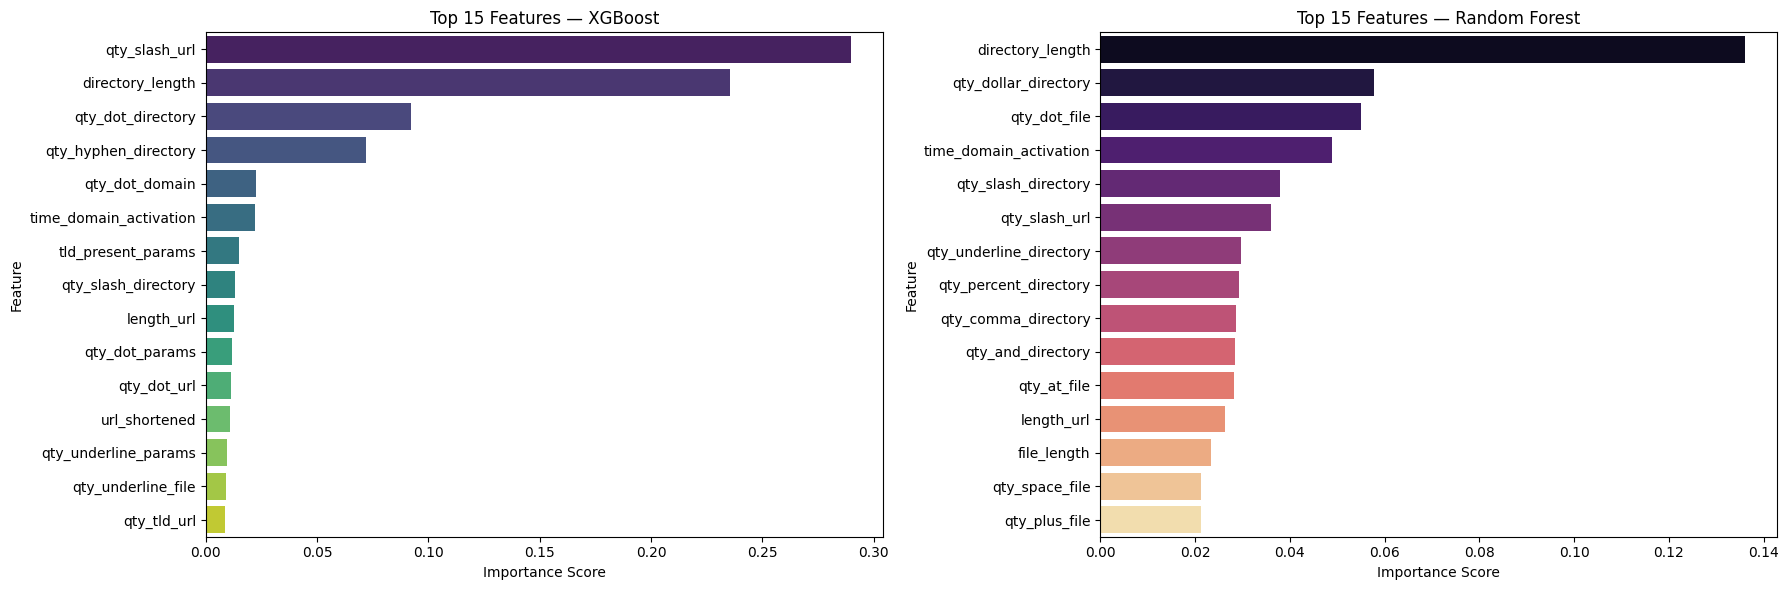

Saved: feature_importance.png


In [31]:
# STEP 8 — Graph 4: Feature Importances — XGBoost vs Random Forest

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# XGBoost feature importance
feat_df = pd.DataFrame({
    "Feature"    : shared_cols,
    "Importance" : model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

sns.barplot(data=feat_df, x="Importance", y="Feature",
            palette="viridis", ax=axes[0])
axes[0].set_title("Top 15 Features — XGBoost")
axes[0].set_xlabel("Importance Score")
axes[0].set_ylabel("Feature")

# Random Forest feature importance
rf_feat_df = pd.DataFrame({
    "Feature"    : shared_cols,
    "Importance" : rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

sns.barplot(data=rf_feat_df, x="Importance", y="Feature",
            palette="magma", ax=axes[1])
axes[1].set_title("Top 15 Features — Random Forest")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")

In [32]:
# STEP 9 — Drift Detection using KS Test
# -------------------------------------------------------
 
print("\nRunning drift detection on dataset_small...")
 
drift_results    = {}
drifted_features = []
 
for col in shared_cols:
    stat, p_value = ks_2samp(X_train[col], X_small[col])
    drifted = p_value < 0.05
    drift_results[col] = {
        "KS Statistic" : round(stat,    4),
        "P-Value"      : round(p_value, 4),
        "Drifted"      : drifted
    }
    if drifted:
        drifted_features.append(col)
 
drift_score = len(drifted_features) / len(shared_cols)
 
print(f"\nDrift detected      : {len(drifted_features) > 0}")
print(f"Features drifted    : {len(drifted_features)} out of {len(shared_cols)}")
print(f"Overall drift score : {drift_score:.0%}")
 
if drifted_features:
    print(f"Drifted features    : {', '.join(drifted_features[:10])}...")
 


Running drift detection on dataset_small...

Drift detected      : True
Features drifted    : 81 out of 111
Overall drift score : 73%
Drifted features    : qty_dot_url, qty_hyphen_url, qty_underline_url, qty_slash_url, qty_equal_url, qty_at_url, qty_and_url, qty_percent_url, qty_tld_url, length_url...


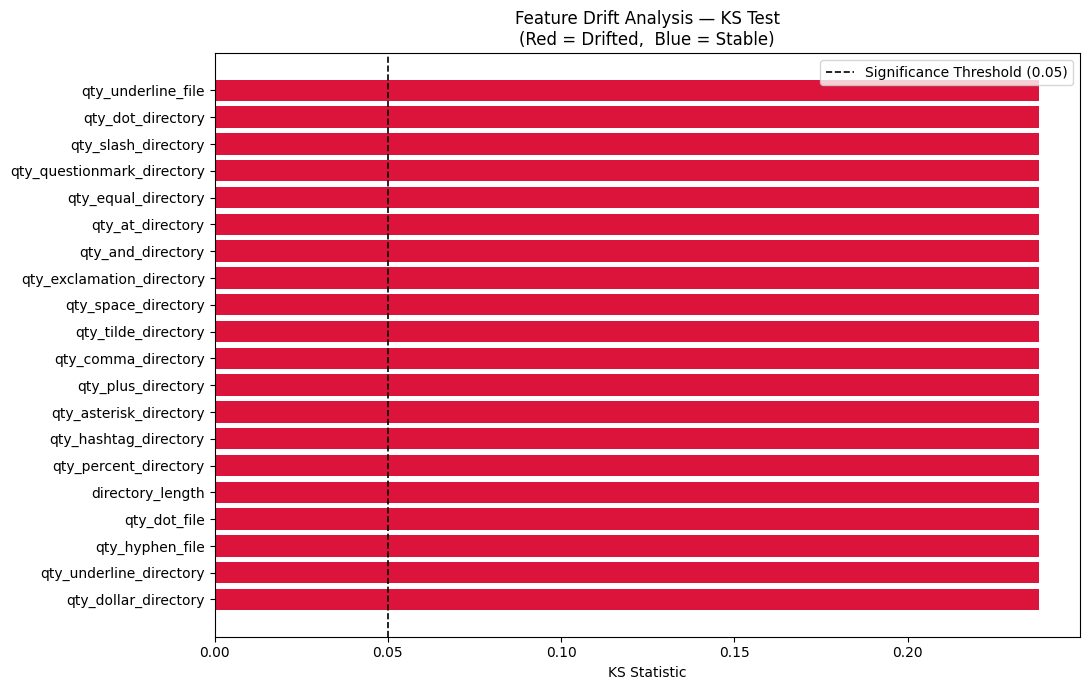

Saved: drift_score_chart.png


In [33]:
# STEP 10 — Graph 5: Drift Score Bar Chart
# -------------------------------------------------------
 
drift_df = pd.DataFrame([
    {"Feature": col, "KS Statistic": v["KS Statistic"], "Drifted": v["Drifted"]}
    for col, v in drift_results.items()
]).sort_values("KS Statistic", ascending=False).head(20)
 
colors = ["crimson" if d else "steelblue" for d in drift_df["Drifted"]]
 
plt.figure(figsize=(11, 7))
plt.barh(drift_df["Feature"], drift_df["KS Statistic"], color=colors)
plt.axvline(x=0.05, color="black", linestyle="--",
            linewidth=1.2, label="Significance Threshold (0.05)")
plt.xlabel("KS Statistic")
plt.title("Feature Drift Analysis — KS Test\n(Red = Drifted,  Blue = Stable)")
plt.legend()
plt.tight_layout()
plt.savefig("drift_score_chart.png", dpi=150)
plt.show()
print("Saved: drift_score_chart.png")
 

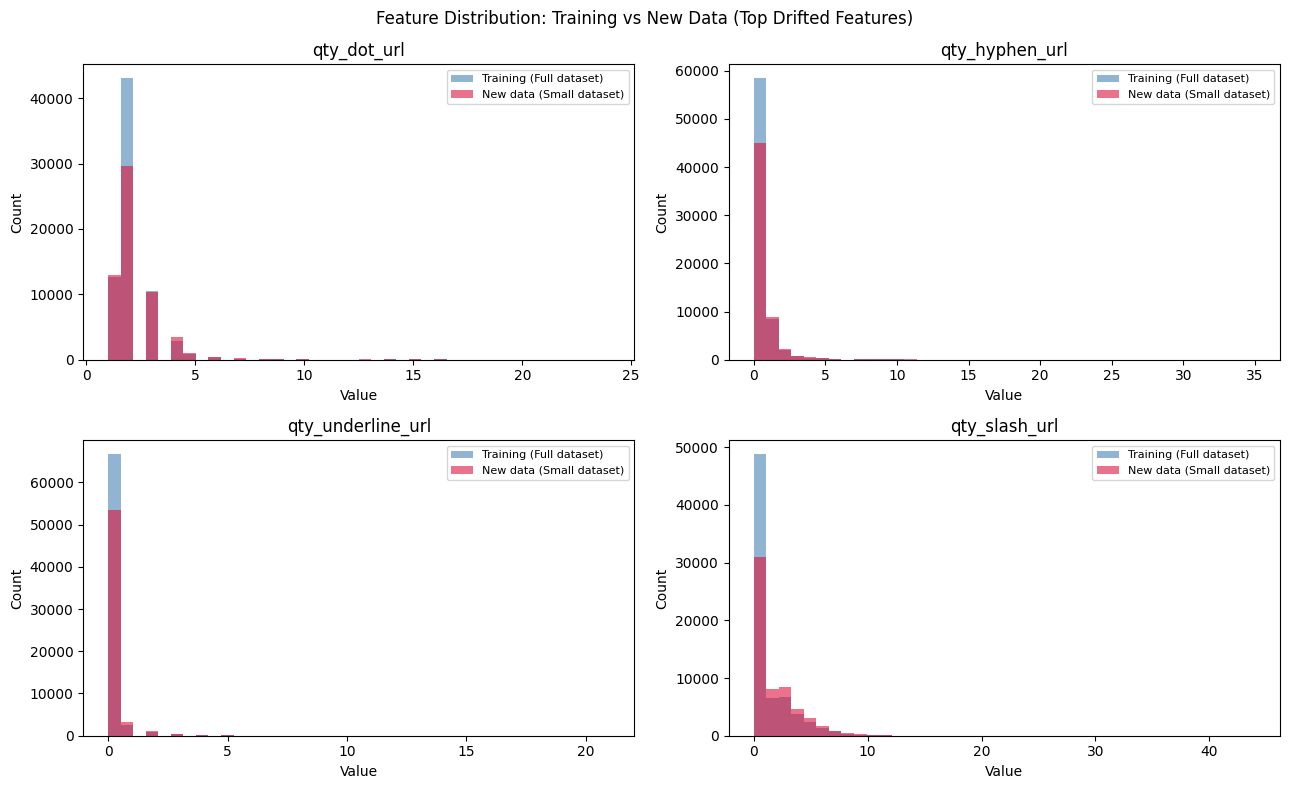

Saved: feature_distribution.png


In [36]:
# STEP 11 — Graph 6: Feature Distribution Before vs After Drift
# -------------------------------------------------------
 
top_drifted = drifted_features[:4] if len(drifted_features) >= 4 else drifted_features
 
if top_drifted:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.flatten()
 
    for i, feat in enumerate(top_drifted):
        axes[i].hist(X_train[feat], bins=40, alpha=0.6,
                     color="steelblue", label="Training (Full dataset)")
        axes[i].hist(X_small[feat], bins=40, alpha=0.6,
                     color="crimson",   label="New data (Small dataset)")
        axes[i].set_title(feat)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Count")
        axes[i].legend(fontsize=8)
 
    for j in range(len(top_drifted), 4):
        axes[j].set_visible(False)
 
    plt.suptitle("Feature Distribution: Training vs New Data (Top Drifted Features)",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig("feature_distribution.png", dpi=150)
    plt.show()
    print("Saved: feature_distribution.png")
 
 

Drift detected in 81 features.
Retraining both models on combined data (full + small)...
XGBoost retraining complete on 129562 total samples.
Retrained XGBoost saved  →  phishing_model_retrained.pkl
Random Forest retraining complete on 129562 total samples.
Retrained Random Forest saved  →  rf_model_retrained.pkl
XGBoost Performance AFTER retraining:
  Accuracy : 95.57%
              precision    recall  f1-score   support

       Legit       0.96      0.95      0.95     27998
    Phishing       0.96      0.96      0.96     30647

    accuracy                           0.96     58645
   macro avg       0.96      0.96      0.96     58645
weighted avg       0.96      0.96      0.96     58645

Random Forest Performance AFTER retraining:
  Accuracy : 93.48%
              precision    recall  f1-score   support

       Legit       0.94      0.92      0.93     27998
    Phishing       0.93      0.95      0.94     30647

    accuracy                           0.93     58645
   macro avg      

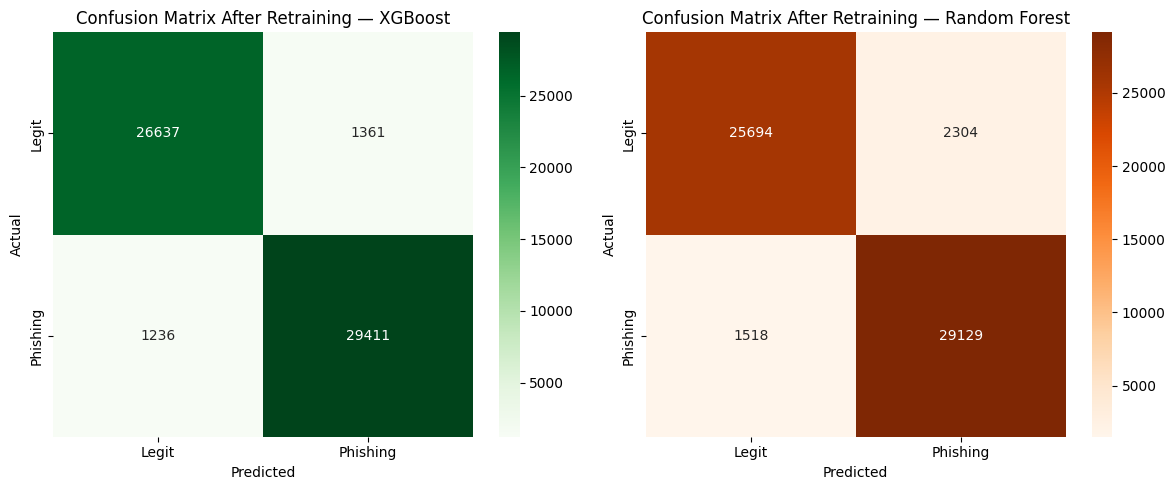

Saved: confusion_matrix_retrained.png
  Final Comparison After Retraining
  XGBoost       Accuracy : 95.57%
  Random Forest Accuracy : 93.48%
  Winner : XGBoost


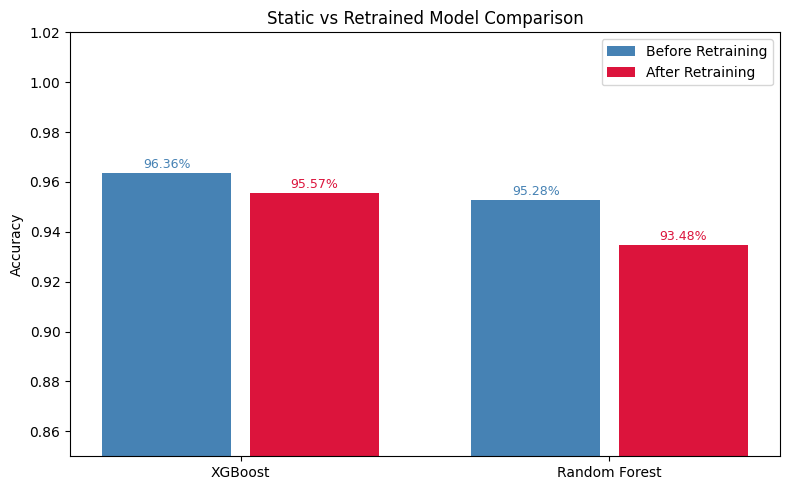

Saved: static_vs_retrained_comparison.png

  Static vs Retrained Summary
  XGBoost  Before : 96.36%  After : 95.57%
  RF       Before : 95.28%  After : 93.48%

  All done! Files saved:
  Models : phishing_model.pkl
           phishing_model_retrained.pkl
           rf_model.pkl
           rf_model_retrained.pkl
  Graphs : confusion_matrix.png
           roc_curve.png
           precision_recall_curve.png
           feature_importance.png
           drift_score_chart.png
           feature_distribution.png
           confusion_matrix_retrained.png
           static_vs_retrained_comparison.png


In [37]:
# STEP 12 — Retrain if drift detected

if len(drifted_features) > 0:
    print(f"Drift detected in {len(drifted_features)} features.")
    print("Retraining both models on combined data (full + small)...")

    X_combined = pd.concat([X_train, X_small], ignore_index=True)
    y_combined = pd.concat([y_train, y_small], ignore_index=True)

    # retrain XGBoost
    model.fit(X_combined, y_combined)
    print(f"XGBoost retraining complete on {len(X_combined)} total samples.")
    joblib.dump(model, "phishing_model_retrained.pkl")
    print("Retrained XGBoost saved  →  phishing_model_retrained.pkl")

    # retrain Random Forest
    rf_model.fit(X_combined, y_combined)
    print(f"Random Forest retraining complete on {len(X_combined)} total samples.")
    joblib.dump(rf_model, "rf_model_retrained.pkl")
    print("Retrained Random Forest saved  →  rf_model_retrained.pkl")

    y_pred_new  = model.predict(X_small)
    rf_pred_new = rf_model.predict(X_small)

    print("XGBoost Performance AFTER retraining:")
    print(f"  Accuracy : {accuracy_score(y_small, y_pred_new):.2%}")
    print(classification_report(y_small, y_pred_new,
                                target_names=["Legit", "Phishing"],
                                labels=[0, 1]))

    print("Random Forest Performance AFTER retraining:")
    print(f"  Accuracy : {accuracy_score(y_small, rf_pred_new):.2%}")
    print(classification_report(y_small, rf_pred_new,
                                target_names=["Legit", "Phishing"],
                                labels=[0, 1]))

    # confusion matrix after retraining — both side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm2 = confusion_matrix(y_small, y_pred_new)
    sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
                xticklabels=["Legit", "Phishing"],
                yticklabels=["Legit", "Phishing"],
                ax=axes[0])
    axes[0].set_title("Confusion Matrix After Retraining — XGBoost")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    cm3 = confusion_matrix(y_small, rf_pred_new)
    sns.heatmap(cm3, annot=True, fmt="d", cmap="Oranges",
                xticklabels=["Legit", "Phishing"],
                yticklabels=["Legit", "Phishing"],
                ax=axes[1])
    axes[1].set_title("Confusion Matrix After Retraining — Random Forest")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.savefig("confusion_matrix_retrained.png", dpi=150)
    plt.show()
    print("Saved: confusion_matrix_retrained.png")

    # final comparison after retraining
    print("=" * 50)
    print("  Final Comparison After Retraining")
    print("=" * 50)
    print(f"  XGBoost       Accuracy : {accuracy_score(y_small, y_pred_new):.2%}")
    print(f"  Random Forest Accuracy : {accuracy_score(y_small, rf_pred_new):.2%}")
    winner = "XGBoost" if accuracy_score(y_small, y_pred_new) >= accuracy_score(y_small, rf_pred_new) else "Random Forest"
    print(f"  Winner : {winner}")
    print("=" * 50)

else:
    print("No significant drift found — model is still reliable.")


# -------------------------------------------------------
# STEP 13 — Graph: Static vs Retrained Model Comparison
# -------------------------------------------------------

xgb_before = accuracy_score(y_test, y_pred)
rf_before  = accuracy_score(y_test, rf_pred)
xgb_after  = accuracy_score(y_small, y_pred_new)
rf_after   = accuracy_score(y_small, rf_pred_new)

models = ["XGBoost", "Random Forest"]
before = [xgb_before, rf_before]
after  = [xgb_after,  rf_after]

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - 0.2, before, 0.35, label="Before Retraining", color="steelblue")
bars2 = ax.bar(x + 0.2, after,  0.35, label="After Retraining",  color="crimson")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Accuracy")
ax.set_title("Static vs Retrained Model Comparison")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.2%}",
            ha="center", fontsize=9, color="steelblue")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.2%}",
            ha="center", fontsize=9, color="crimson")

plt.tight_layout()
plt.savefig("static_vs_retrained_comparison.png", dpi=150)
plt.show()
print("Saved: static_vs_retrained_comparison.png")

print("\n" + "=" * 50)
print("  Static vs Retrained Summary")
print("=" * 50)
print(f"  XGBoost  Before : {xgb_before:.2%}  After : {xgb_after:.2%}")
print(f"  RF       Before : {rf_before:.2%}  After : {rf_after:.2%}")
print("=" * 50)


# -------------------------------------------------------
# DONE
# -------------------------------------------------------

print("\n" + "=" * 55)
print("  All done! Files saved:")
print("  Models : phishing_model.pkl")
print("           phishing_model_retrained.pkl")
print("           rf_model.pkl")
print("           rf_model_retrained.pkl")
print("  Graphs : confusion_matrix.png")
print("           roc_curve.png")
print("           precision_recall_curve.png")
print("           feature_importance.png")
print("           drift_score_chart.png")
print("           feature_distribution.png")
print("           confusion_matrix_retrained.png")
print("           static_vs_retrained_comparison.png")
print("=" * 55)